## Financial News Sentiment Analysis

### Libraries

In [1]:
# import libraries
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..'))) # Adding racine path of project to sys.path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
from src.preprocessing import * # Module created

warnings.filterwarnings('ignore')

### Import data and preprocessing

In [2]:
df = wrangle('../data/raw_analyst_ratings.csv') #Preprocessing function defined in src module
df.info()
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 1407327 entries, 2020-06-05 14:30:54+00:00 to 2011-05-12 00:00:00+00:00
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   headline   1407327 non-null  str  
 1   url        1407327 non-null  str  
 2   publisher  1407327 non-null  str  
 3   stock      1407327 non-null  str  
dtypes: str(4)
memory usage: 53.7 MB


,headline,url,publisher,stock
date,,,,
2020-06-05 14:30:54+00:00,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,A
2020-06-03 14:45:20+00:00,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,A
2020-05-26 08:30:07+00:00,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,A
2020-05-22 16:45:06+00:00,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,A
2020-05-22 15:38:59+00:00,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,A


### Exploratory Data Analysis

#### Descriptive statistics

In [3]:
# Headline length
df["headline_length"] = df["headline"].apply(lambda i: len(i))
df.head()

,headline,url,publisher,stock,headline_length
date,,,,,
2020-06-05 14:30:54+00:00,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,A,39
2020-06-03 14:45:20+00:00,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,A,42
2020-05-26 08:30:07+00:00,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,A,29
2020-05-22 16:45:06+00:00,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,A,44
2020-05-22 15:38:59+00:00,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,A,87


In [4]:
df["headline_length"].describe()

count    1.407327e+06
mean     7.312054e+01
std      4.073532e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [5]:
# The database possess duplicates on subset columns "headline" and "publisher"
df.duplicated(subset=["headline","publisher"]).sum()

np.int64(555383)

In [6]:
# To access to the real number of articles per publisher, we need to drop duplicates on subset 
# columns "headline" and "publisher"
df_clean = df.drop_duplicates(subset=["headline","publisher"])

In [7]:
stats_publisher = df_clean["publisher"].value_counts()
stats_publisher = stats_publisher.reset_index()
stats_publisher.columns = ["publisher","count"]
top_publishers = stats_publisher.head(10)
top_publishers

,publisher,count
0,Paul Quintaro,210483
1,Benzinga Newsdesk,93272
2,Charles Gross,82143
3,Eddie Staley,53843
4,Hal Lindon,43392
5,Juan Lopez,27714
6,Vick Meyer,24658
7,Benzinga Staff,22644
8,Monica Gerson,21638
9,Benzinga_Newsdesk,18198


Text(0, 0.5, 'Publisher')

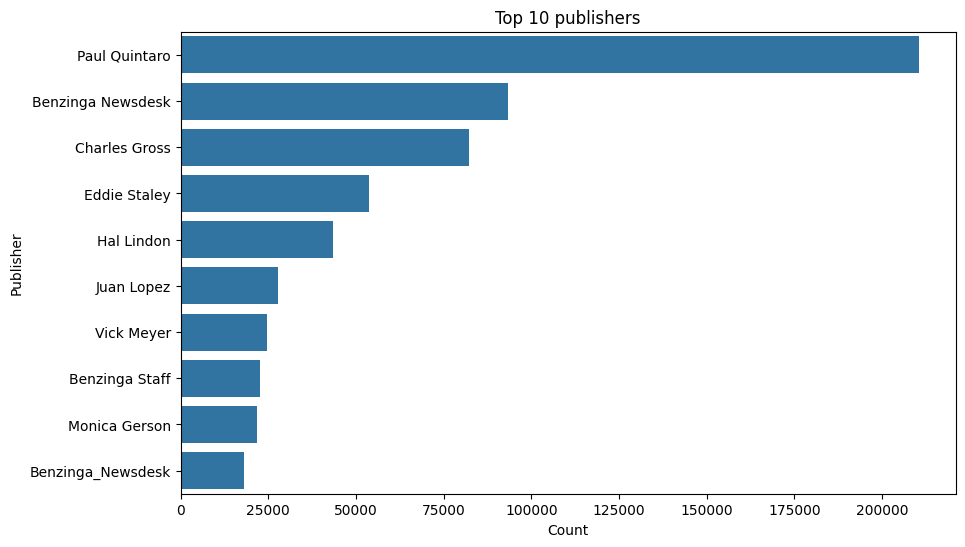

In [ ]:
# Graph of the top 10 publishers
plt.figure(figsize=(10,6))
sns.barplot(x="count",y="publisher",data=top_publishers)
plt.title("Top 10 publishers")
plt.xlabel("Count")
plt.ylabel("Publisher")

#### Trend analysis of the publications

##### Day trend analysis

In [9]:
# We have data that are going from 2009-02-14 till 2020-06-11.
# Let's try to see the distribution of articles over day of the week
# We should use the clean database to avoid duplicates on subset columns "headline" and "publisher"

trend_per_day = df_clean.index.day_name().value_counts()
trend_per_day

date
Thursday     188552
Wednesday    186497
Tuesday      184092
Monday       160605
Friday       123641
Sunday         5610
Saturday       2947
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of publications per day')

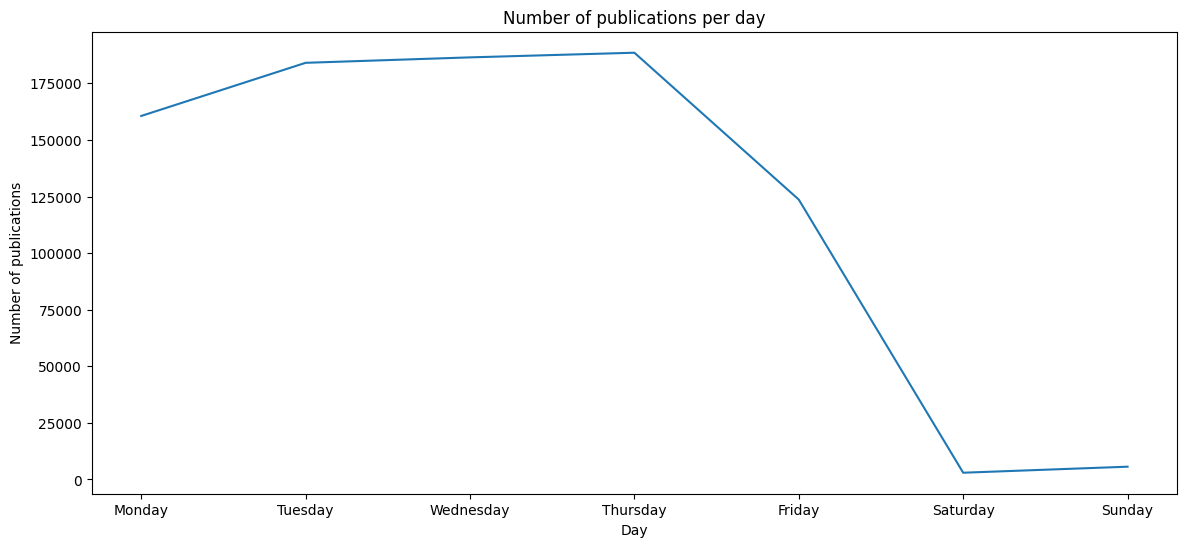

In [11]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trend_per_day = trend_per_day.reindex(days_order)
plt.figure(figsize=(14,6))
trend_per_day.plot()
plt.xlabel('Day')
plt.ylabel('Number of publications')
plt.title('Number of publications per day')

We notice that more of the articles are publish on work days (Monday to Friday) and week end days save less publications. The pic of publications is reach on Thursday

##### Month trend analysis

We have data that are going from 2009-02-14 till 2020-06-11. Since we don't have full year for 2009 and 2020, we are going reduce our data from 2009-06-11 till 2020-06-11 in order to appreciate the trends of publications per month.

In [13]:
df1 = df_clean.sort_index()
df1.head()

,headline,url,publisher,stock,headline_length
date,,,,,
2009-02-14 00:00:00+00:00,How Treasuries and ETFs Work,https://www.benzinga.com/28044/how-treasuries-...,Paco Ahlgren,NAV,28
2009-04-27 00:00:00+00:00,Update on the Luxury Sector: 2nd Quarter 2009,https://www.benzinga.com/charles-lewis-sizemor...,Charles Lewis Sizemore CFA,FT,45
2009-04-29 00:00:00+00:00,Going Against the Herd,https://www.benzinga.com/charles-lewis-sizemor...,Charles Lewis Sizemore CFA,A,22
2009-05-22 00:00:00+00:00,Charles Sizemore Radio Interview Saturday Morning,https://www.benzinga.com/11218/charles-sizemor...,Charles Lewis Sizemore CFA,AM,49
2009-05-27 00:00:00+00:00,"JVA perks to 39% gain, SMCG ready, MRM to cont...",https://www.benzinga.com/superman/2009/5/27/jv...,superman,EPS,50


In [14]:
df1 = df1.loc['2009-06-11':'2020-06-11']
df1.head()

,headline,url,publisher,stock,headline_length
date,,,,,
2009-06-15 00:00:00+00:00,super-trades Momentum Continues With Staying P...,https://www.benzinga.com/5335/super-trades-mom...,superman,EFUT,50
2009-06-15 00:00:00+00:00,In AIM $4.20,https://www.benzinga.com/5336/in-aim-4-20,superman,EPS,12
2009-06-16 00:00:00+00:00,RINO.OB - Amazing Growth - Compare to Coming D...,https://www.benzinga.com/5333/rino-ob-amazing-...,superman,EPS,52
2009-06-16 00:00:00+00:00,AIM Great News the Day After Great Earnings,https://www.benzinga.com/5334/aim-great-news-t...,superman,EPS,43
2009-06-19 00:00:00+00:00,Review of 3 Chinese IPO's- Week of June 22nd,https://www.benzinga.com/5332/review-of-3-chin...,superman,ADS,44


In [15]:
trend_per_month = df1.index.month_name().value_counts()
trend_per_month.sort_values(ascending=False)

date
May          81874
February     77365
October      76989
April        76832
November     74194
January      74028
August       71767
March        71194
July         69270
June         61805
December     61159
September    55451
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of publications based per month')

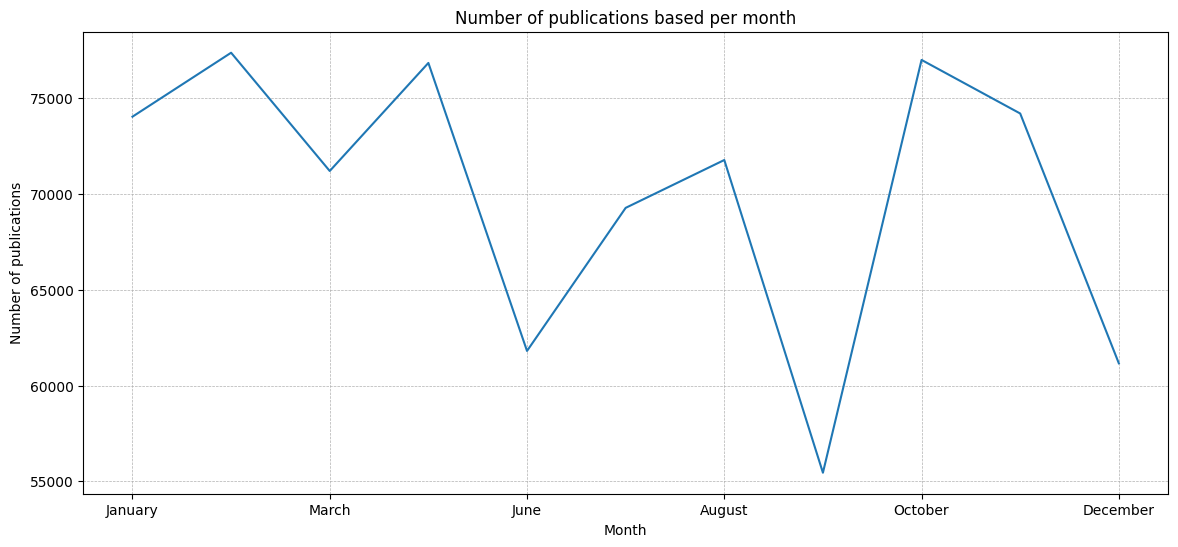

In [16]:
month_order = ['January', 'February', 'March', 'April', 'June', 'July', 'August', 'September', 'October',
               'November', 'December']

trend_per_month = trend_per_month.reindex(month_order)
plt.figure(figsize=(14,6))
trend_per_month.plot()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel('Month')
plt.ylabel('Number of publications')
plt.title('Number of publications based per month')

We notice that September month saved less of publication than other months while May month saved the higher number of publications.